In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
print('done')

done


# Load Datasets

In [4]:
df = pd.read_csv("Datasets/dataset.csv")
df.head()

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df1 = pd.read_csv("Datasets/symptom_Description.csv")
df2 = pd.read_csv("Datasets/symptom_precaution.csv")
df3 = pd.read_csv("Datasets/Symptom-severity.csv")

# imformation about this all  datasets

In [6]:
print(f'   dataset.csv      → {df.shape[0]} rows, {df.shape[1]} columns')
print(f'   Description.csv  → {df1.shape[0]} rows')
print(f'   Precaution.csv   → {df2.shape[0]} rows')
print(f'   Severity.csv     → {df3.shape[0]} rows')

   dataset.csv      → 4920 rows, 18 columns
   Description.csv  → 41 rows
   Precaution.csv   → 41 rows
   Severity.csv     → 133 rows


# dataset.csv info

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Disease     4920 non-null   object
 1   Symptom_1   4920 non-null   object
 2   Symptom_2   4920 non-null   object
 3   Symptom_3   4920 non-null   object
 4   Symptom_4   4572 non-null   object
 5   Symptom_5   3714 non-null   object
 6   Symptom_6   2934 non-null   object
 7   Symptom_7   2268 non-null   object
 8   Symptom_8   1944 non-null   object
 9   Symptom_9   1692 non-null   object
 10  Symptom_10  1512 non-null   object
 11  Symptom_11  1194 non-null   object
 12  Symptom_12  744 non-null    object
 13  Symptom_13  504 non-null    object
 14  Symptom_14  306 non-null    object
 15  Symptom_15  240 non-null    object
 16  Symptom_16  192 non-null    object
 17  Symptom_17  72 non-null     object
dtypes: object(18)
memory usage: 692.0+ KB


# missing values

In [8]:
df.isnull().sum()

Disease          0
Symptom_1        0
Symptom_2        0
Symptom_3        0
Symptom_4      348
Symptom_5     1206
Symptom_6     1986
Symptom_7     2652
Symptom_8     2976
Symptom_9     3228
Symptom_10    3408
Symptom_11    3726
Symptom_12    4176
Symptom_13    4416
Symptom_14    4614
Symptom_15    4680
Symptom_16    4728
Symptom_17    4848
dtype: int64

# all diseases in dataset

In [9]:
for i, disease in enumerate(sorted(df['Disease'].unique()), 1):
    print(f'{i:2}. {disease}')

 1. (vertigo) Paroymsal  Positional Vertigo
 2. AIDS
 3. Acne
 4. Alcoholic hepatitis
 5. Allergy
 6. Arthritis
 7. Bronchial Asthma
 8. Cervical spondylosis
 9. Chicken pox
10. Chronic cholestasis
11. Common Cold
12. Dengue
13. Diabetes 
14. Dimorphic hemmorhoids(piles)
15. Drug Reaction
16. Fungal infection
17. GERD
18. Gastroenteritis
19. Heart attack
20. Hepatitis B
21. Hepatitis C
22. Hepatitis D
23. Hepatitis E
24. Hypertension 
25. Hyperthyroidism
26. Hypoglycemia
27. Hypothyroidism
28. Impetigo
29. Jaundice
30. Malaria
31. Migraine
32. Osteoarthristis
33. Paralysis (brain hemorrhage)
34. Peptic ulcer diseae
35. Pneumonia
36. Psoriasis
37. Tuberculosis
38. Typhoid
39. Urinary tract infection
40. Varicose veins
41. hepatitis A


# remove extra space from string

In [10]:
df = df.apply(lambda col: col.str.strip() if col.dtype == 'object' else col)

# fill missing values with 0

In [11]:
df = df.fillna(0)
df.isnull().sum().sum()

np.int64(0)

# all unique symptoms

In [12]:
symptoms = []

for col in df.columns[1:]:      
    for val in df[col].tolist():
        if val != 0:              
            symptoms.append(val)

symptoms = sorted(list(set(symptoms)))

print(f'total unique symptoms {len(symptoms)}')
print()
for i, s in enumerate(symptoms, 1):
    print(f'{i:3}. {s}')

total unique symptoms 131

  1. abdominal_pain
  2. abnormal_menstruation
  3. acidity
  4. acute_liver_failure
  5. altered_sensorium
  6. anxiety
  7. back_pain
  8. belly_pain
  9. blackheads
 10. bladder_discomfort
 11. blister
 12. blood_in_sputum
 13. bloody_stool
 14. blurred_and_distorted_vision
 15. breathlessness
 16. brittle_nails
 17. bruising
 18. burning_micturition
 19. chest_pain
 20. chills
 21. cold_hands_and_feets
 22. coma
 23. congestion
 24. constipation
 25. continuous_feel_of_urine
 26. continuous_sneezing
 27. cough
 28. cramps
 29. dark_urine
 30. dehydration
 31. depression
 32. diarrhoea
 33. dischromic _patches
 34. distention_of_abdomen
 35. dizziness
 36. drying_and_tingling_lips
 37. enlarged_thyroid
 38. excessive_hunger
 39. extra_marital_contacts
 40. family_history
 41. fast_heart_rate
 42. fatigue
 43. fluid_overload
 44. foul_smell_of urine
 45. headache
 46. high_fever
 47. hip_joint_pain
 48. history_of_alcohol_consumption
 49. increased_appetite

# endcode the symptoms


In [13]:
print('Encoding symptoms... please wait...')
encoded_df = pd.DataFrame(0, index=df.index, columns=symptoms)

for idx, row in df.iterrows():
    for col in df.columns[1:]:   
        symptom = row[col]
        if symptom != 0:       
            encoded_df.at[idx, symptom] = 1

encoded_df['Disease'] = df['Disease'].values

print(f'   Rows    : {encoded_df.shape[0]}')
print(f'   Columns : {encoded_df.shape[1]}  (131 symptoms + 1 Disease)')

Encoding symptoms... please wait...
   Rows    : 4920
   Columns : 132  (131 symptoms + 1 Disease)


In [14]:
encoded_df.iloc[:5 , :8]

,abdominal_pain,abnormal_menstruation,acidity,acute_liver_failure,altered_sensorium,anxiety,back_pain,belly_pain
0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0


# save cleaned file

In [15]:
import os
os.makedirs('cleaned', exist_ok = True)
encoded_df.to_csv('cleaned/cleanedSet.csv', index = False)


# disease frequency visualization

C:\Users\DHRUV\AppData\Local\Temp\ipykernel_24676\4160231430.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=disease_counts.index, y=disease_counts.values, palette='Blues_r')


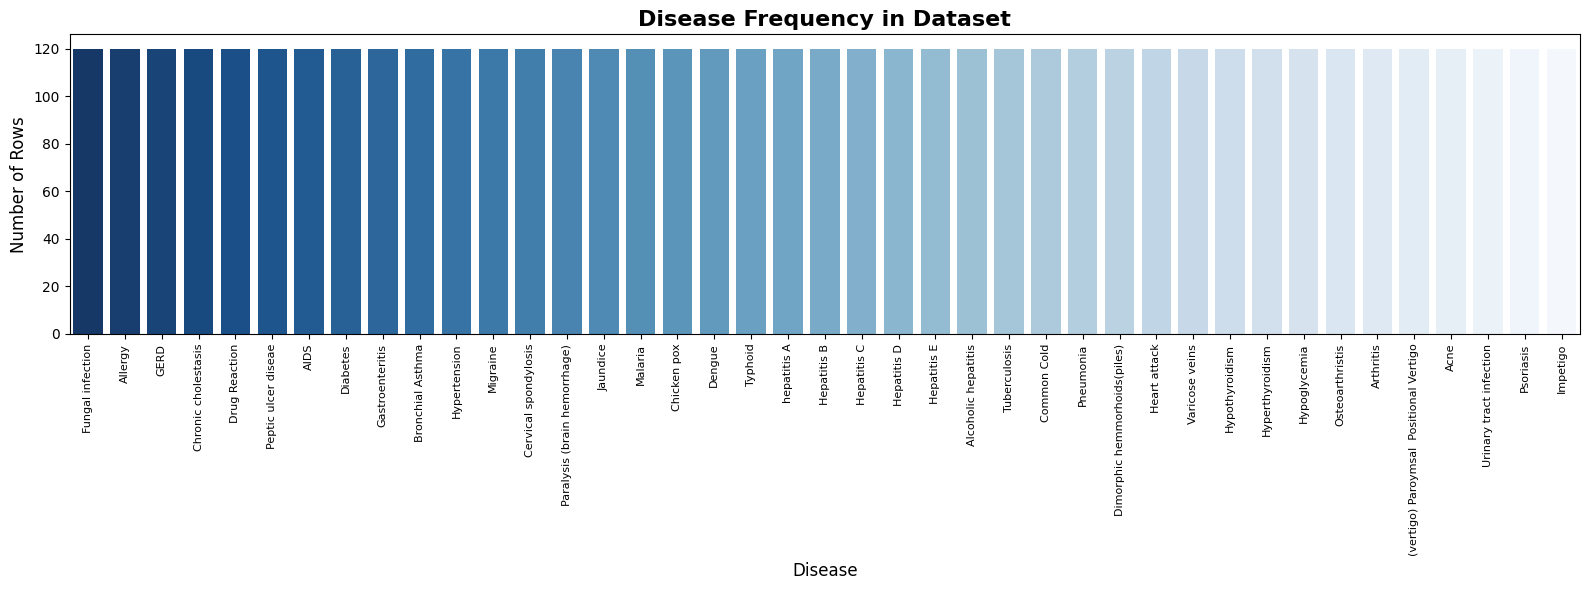

In [16]:
plt.figure(figsize=(16, 6))
disease_counts = df['Disease'].value_counts()
sns.barplot(x=disease_counts.index, y=disease_counts.values, palette='Blues_r')
plt.title('Disease Frequency in Dataset', fontsize=16, fontweight='bold')
plt.xlabel('Disease', fontsize=12)
plt.ylabel('Number of Rows', fontsize=12)
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.savefig('disease_frequency.png', dpi=150)
plt.show()

# top 20 servere symptoms

C:\Users\DHRUV\AppData\Local\Temp\ipykernel_24676\3652132056.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Symptom', y='weight', data=sev_sorted, palette='Reds_r')


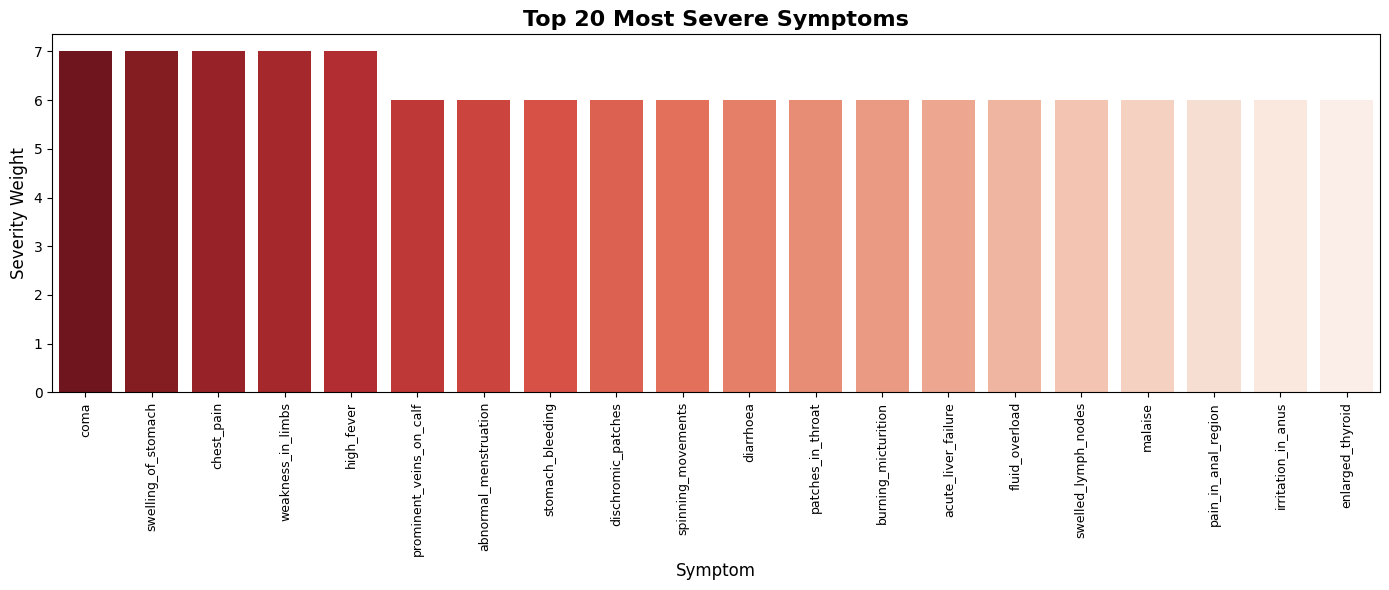

In [18]:
sev_sorted = df3.sort_values('weight', ascending=False).head(20)

plt.figure(figsize=(14, 6))
sns.barplot(x='Symptom', y='weight', data=sev_sorted, palette='Reds_r')
plt.title('Top 20 Most Severe Symptoms', fontsize=16, fontweight='bold')
plt.xlabel('Symptom', fontsize=12)
plt.ylabel('Severity Weight', fontsize=12)
plt.xticks(rotation=90, fontsize=9)
plt.tight_layout()
plt.savefig('symptom_severity.png', dpi=150)
plt.show()

# most common symptoms

C:\Users\DHRUV\AppData\Local\Temp\ipykernel_24676\4071273973.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=symptom_counts.index, y=symptom_counts.values, palette='Greens_r')


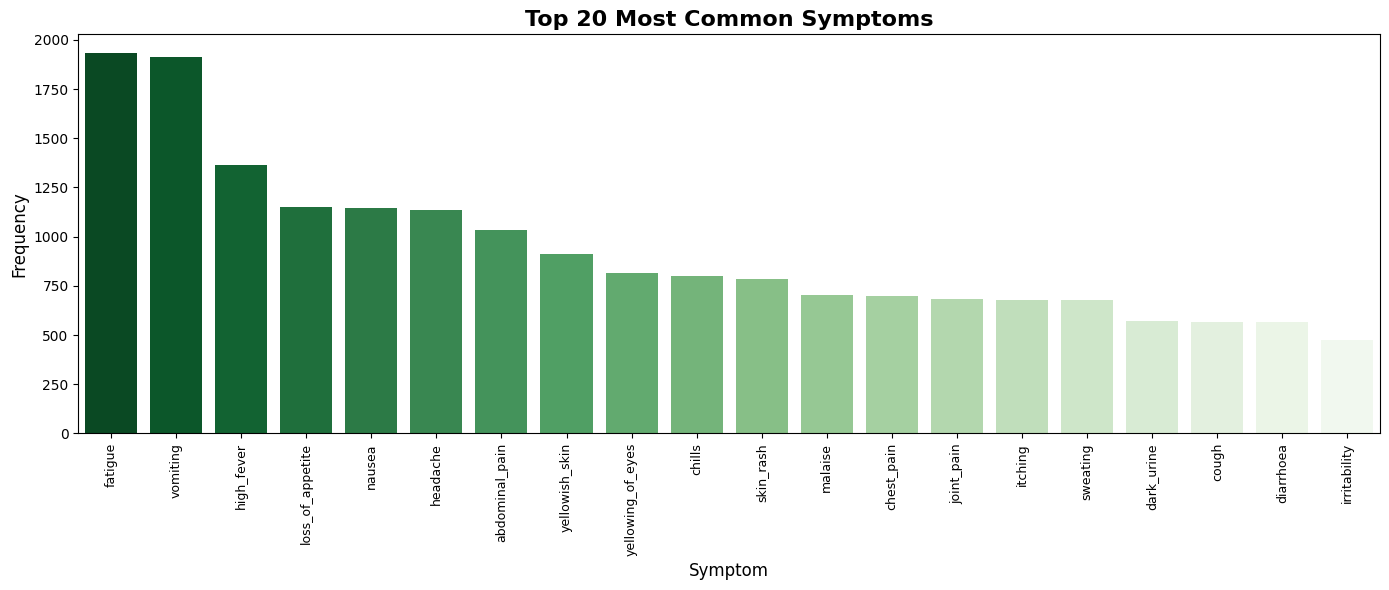

In [19]:
symptom_counts = encoded_df[symptoms].sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(14, 6))
sns.barplot(x=symptom_counts.index, y=symptom_counts.values, palette='Greens_r')
plt.title('Top 20 Most Common Symptoms', fontsize=16, fontweight='bold')
plt.xlabel('Symptom', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=90, fontsize=9)
plt.tight_layout()
plt.savefig('common_symptoms.png', dpi=150)
plt.show()

# split data for traning

In [20]:
X = encoded_df.drop('Disease', axis=1)
y = encoded_df['Disease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Data split complete!')
print(f'Training samples : {X_train.shape[0]}')
print(f'Testing samples  : {X_test.shape[0]}')
print(f'Total features   : {X_train.shape[1]} symptoms')

Data split complete!
Training samples : 3936
Testing samples  : 984
Total features   : 131 symptoms


# train random forest model

In [21]:
print('traning start')
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print('done')

traning start
done


# check model acuracy

In [22]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'model accuracy: {accuracy * 100:.2f}%')

model accuracy: 100.00%


In [23]:
print('classification report')
print(classification_report(y_test, y_pred))

classification report
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00        18
                                   AIDS       1.00      1.00      1.00        30
                                   Acne       1.00      1.00      1.00        24
                    Alcoholic hepatitis       1.00      1.00      1.00        25
                                Allergy       1.00      1.00      1.00        24
                              Arthritis       1.00      1.00      1.00        23
                       Bronchial Asthma       1.00      1.00      1.00        33
                   Cervical spondylosis       1.00      1.00      1.00        23
                            Chicken pox       1.00      1.00      1.00        21
                    Chronic cholestasis       1.00      1.00      1.00        15
                            Common Cold       1.00      1.00      1.00        23
     

# save model

In [24]:
os.makedirs('model', exist_ok=True)
with open('model/model.pkl', 'wb') as f:
    pickle.dump(model, f)
with open('model/symptoms_list.pkl', 'wb') as f:
    pickle.dump(symptoms, f)
print('done')

done


In [26]:
def get_description(disease):
    row = df1[df1['Disease'] == disease]
    if not row.empty:
        return row['Description'].values[0]
    return 'Description not available'

def get_precautions(disease):
    row = df2[df2['Disease'] == disease]
    if not row.empty:
        return row[['Precaution_1','Precaution_2',
                    'Precaution_3','Precaution_4']].values[0].tolist()
    return ['Not available'] * 4

def get_severity(user_symptoms):
    score = 0
    for symptom in user_symptoms:
        row = df3[df3['Symptom'] == symptom]
        if not row.empty:
            score += row['weight'].values[0]
    if score <= 15:
        level = '🟢 Mild — Safe, try home remedies'
    elif score <= 30:
        level = '🟡 Moderate — Consult a doctor soon'
    else:
        level = '🔴 Critical — Visit hospital immediately!'
    return score, level

print('All fetch functions ready!')

All fetch functions ready!


In [27]:
def predict_disease(input_symptoms):
    """
    Takes a list of symptoms and returns:
    - Predicted disease
    - Disease description
    - Precautions
    - Severity
    """
    input_df = pd.DataFrame(0, index=[0], columns=symptoms)
    

    for symptom in input_symptoms:
        if symptom in symptoms:
            input_df[symptom] = 1
    
   
    prediction = model.predict(input_df)[0]
    
  
    proba = model.predict_proba(input_df)[0]
    confidence = max(proba) * 100
 
    description = df1[df1['Disease'] == prediction]['Description'].values
    description = description[0] if len(description) > 0 else "No description available"
    

    precautions = df2[df2['Disease'] == prediction][['Precaution_1', 'Precaution_2', 'Precaution_3', 'Precaution_4']].values
    
    return {
        'Disease': prediction,
        'Confidence': f"{confidence:.2f}%",
        'Description': description,
        'Precautions': precautions[0] if len(precautions) > 0 else [],
        'Input_Symptoms': input_symptoms
    }

print("Prediction function created!")
print("\nUsage Example:")
print("result = predict_disease(['symptom1', 'symptom2', 'symptom3'])")


Prediction function created!

Usage Example:
result = predict_disease(['symptom1', 'symptom2', 'symptom3'])
